# 4.0 Model training - LightGBM


## Imports


In [26]:
import numpy as np
import pandas as pd
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.modeling.train import (
    build_feature_drop_list,
    load_data,
    prepare_features,
    lgbm_gridsearch,
    shap_fs,
    boruta_fs,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred, plot_feature_importances
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable, get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

In [21]:
CV_SPLITS = 3
TEST_SIZE = 0.2
DROP_COLUMNS = [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_NBR_COL, DAY_OF_WEEK_COL, CITY_COL]

FS_TOP_K = 35
PERM_N_REPEATS = 5
FS_VALID_SIZE = 0.2

MODEL_PATH = MODELS_DIR / "lightgbm_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 50)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Feature selection

In [6]:
param_grid = [
    {
        "model__learning_rate": [0.01, 0.05],
        "model__n_estimators": [100, 150],
        "model__max_depth": [4, 5],
        "model__min_child_samples": [10, 20],
        "model__reg_alpha": [0, 1],
        "model__reg_lambda": [0, 0.1]
    }
]

light_grid_search = lgbm_gridsearch(
    param_grid=param_grid,
    n_splits=5,
    verbose=0,
    n_jobs=-1,
    drop_features=DROP_COLUMNS,
)
light_grid_search.fit(X_train, y_train)
lgbm = light_grid_search.best_estimator_

Fitting 5 folds for each of 64 candidates, totalling 320 fits


C:\Users\lymuthien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [-0.97453648 -0.9742969  -0.9743013  -0.97450516 -0.89972682 -0.89959993
 -0.89943644 -0.89958005 -0.97408815 -0.97411494 -0.97427804 -0.97404563
 -0.89916433 -0.8994752  -0.8991695  -0.89940395 -0.96253804 -0.96262067
 -0.96262925 -0.9626471  -0.88384658 -0.88383664 -0.88405898 -0.88394983
 -0.96202627 -0.96188952 -0.96189453 -0.96170329 -0.88305503 -0.88288791
 -0.88282048 -0.88272514         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan]
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9079
[LightGBM] [Info] Number of data points in the train set: 197104, number of used features: 45
[LightGBM] [Info] Start training from score 17.605584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [11]:
X_trans = lgbm.named_steps["feature_dropper"].transform(X_train)
selected_features, statuses = boruta_fs(
    X_trans,
    y_train,
    lgbm.named_steps["model"],
)

FEATURES_TO_DROP = build_feature_drop_list(
    X.columns.tolist(),
    selected_features,
)
FEATURES_TO_KEEP = [c for c in X.columns if c not in FEATURES_TO_DROP]

print("Selected features: ", selected_features)

Selected features:  ['holiday_flg', 'open_usually', 'total_reserves', 'total_reserves_nbrs', 'visitors_mean_7', 'visitors_median_7', 'visitors_std_7', 'visitors_mean_14', 'visitors_median_14', 'visitors_std_14', 'visitors_mean_28', 'visitors_median_28', 'visitors_std_28', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_28', 'visitors_nbrs_lag_1', 'visitors_dow_mean', 'visitors_dow_mean_nbrs', 'res_visitors_diff', 'res_visitors_diff_mean_7', 'res_visitors_diff_mean_14', 'res_visitors_diff_mean_28', 'nbr_res_visitors_diff', 'nbr_res_visitors_diff_mean_28']


## Training


In [13]:
params = {
    "model__learning_rate": np.logspace(-2, -0.7, 5),
    "model__n_estimators": [150, 175, 200],
    "model__min_child_samples": [10, 20, 30],
    "model__reg_alpha": [0.0, 0.1, 1.0],
    "model__reg_lambda": [0.0, 0.1, 1.0],
}
param_grid = [
    {
        **params,
        "model__max_depth": [4],
        "model__num_leaves": [7, 11, 15],
    },
    {
        **params,
        "model__max_depth": [5],
        "model__num_leaves": [20, 25, 31],
    },
]

In [14]:
grid_search = lgbm_gridsearch(
    param_grid=param_grid,
    verbose=3,
    n_jobs=-1,
    drop_features=FEATURES_TO_DROP,
    n_splits=CV_SPLITS,
)
grid_search.fit(X_train, y_train)
best_idx = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)
print(f"Best score: {grid_search.cv_results_["mean_test_score"][best_idx]:.5f}")
print(f"CV std: {grid_search.cv_results_["std_test_score"][best_idx]:.5f}")

Fitting 3 folds for each of 2430 candidates, totalling 7290 fits


C:\Users\lymuthien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [-0.92538213 -0.92527672 -0.92462576 ...         nan         nan
         nan]
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5020
[LightGBM] [Info] Number of data points in the train set: 197104, number of used features: 25
[LightGBM] [Info] Start training from score 17.605584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [15]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__min_child_samples,param_model__n_estimators,param_model__num_leaves,param_model__reg_alpha,param_model__reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1533,9.388703,0.731030,0.009620,0.000636,0.021135,5,10,200,31,0.1,0.0,"{'model__learning_rate': 0.021134890398366465,...",-0.632460,-0.629826,-0.836291,-0.699526,0.096714,1
1537,13.678203,0.722295,0.008869,0.000688,0.021135,5,10,200,31,1.0,0.1,"{'model__learning_rate': 0.021134890398366465,...",-0.631844,-0.629973,-0.837634,-0.699817,0.097455,2
1532,8.620040,0.619233,0.009819,0.000663,0.021135,5,10,200,31,0.0,1.0,"{'model__learning_rate': 0.021134890398366465,...",-0.632690,-0.630237,-0.836664,-0.699863,0.096738,3
1534,9.684325,1.734742,0.010644,0.001317,0.021135,5,10,200,31,0.1,0.1,"{'model__learning_rate': 0.021134890398366465,...",-0.633077,-0.630301,-0.836831,-0.700070,0.096711,4
1535,13.497925,0.698938,0.010401,0.000106,0.021135,5,10,200,31,0.1,1.0,"{'model__learning_rate': 0.021134890398366465,...",-0.632391,-0.631368,-0.836832,-0.700197,0.096616,5


In [16]:
model = grid_search.best_estimator_
y_train_pred = model.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.8789
MAE:  6.9067
R2:   0.6114


In [21]:
y_test_pred, temp_features = recursive_predict(
    model,
    X_test,
    X_train,
    y_train,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.83158722e+01 1.25756508e+01 8.42635476e+00 5.40041336e+00
 4.94585946e+00 1.93144036e+01 1.25470726e+01 3.98503515e+01
 3.11334787e+01 7.37487004e+00 3.09322418e+01 3.73363014e+00
 1.89898054e+01 2.97310354e+01 1.36995297e+01 9.21833530e+00
 9.23122011e-01 7.01474589e+00 2.79090584e+00 2.75377778e+01
 2.10858070e+01 4.02799528e+01 5.94512644e+00 1.10092221e+01
 9.54377539e+00 1.56081361e+01 4.05330800e+00 1.06605768e+01
 8.14280354e+00 2.49625910e+01 0.00000000e+00 4.44818426e+01
 2.51827094e+01 6.01181554e+00 5.66147148e-01 2.85799312e+01
 8.59081716e+00 3.79399896e+00 1.13551562e+01 9.65084848e+00
 1.35527558e+00 7.31627430e+00 1.43728120e+01 5.56155026e+00
 1.97605997e-01 1.89762422e+01 9.32283377e+00 3.93620

In [22]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8353
MAE:  7.1042
R2:   0.5571


## Graphs

### Feature importances

<Figure size 1200x1000 with 0 Axes>

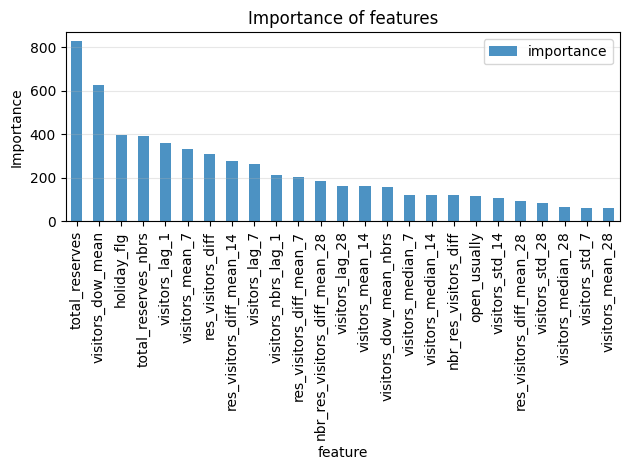

In [17]:
plot_feature_importances(model, FEATURES_TO_KEEP)

## SHAP explanation

In [18]:
X_test_clean = model.named_steps["feature_dropper"].transform(X_test)
lgbm = model.named_steps["model"]

explainer = shap.Explainer(lgbm)
shap_values = explainer(X_test_clean)

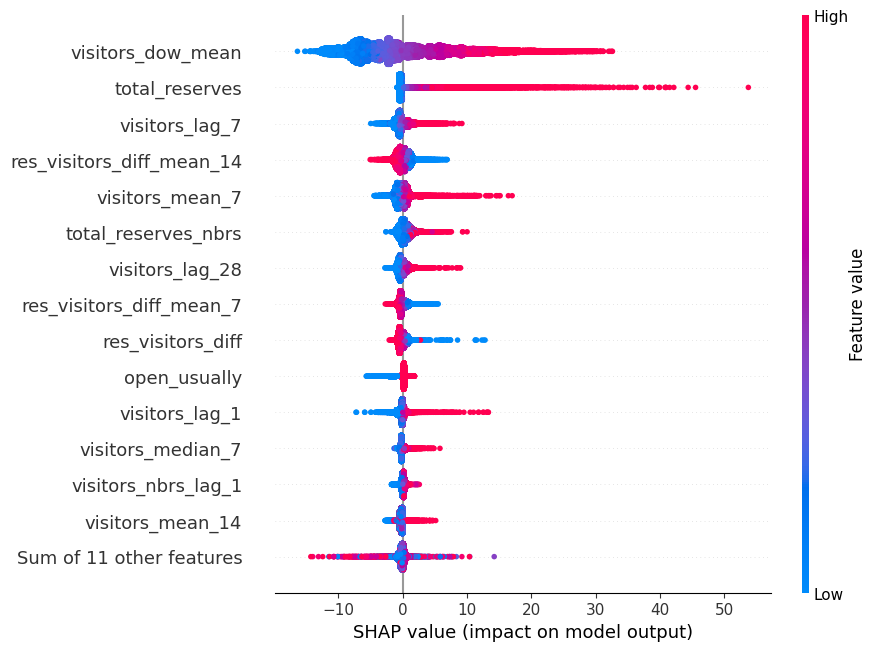

In [19]:
shap.plots.beeswarm(shap_values, max_display=15)

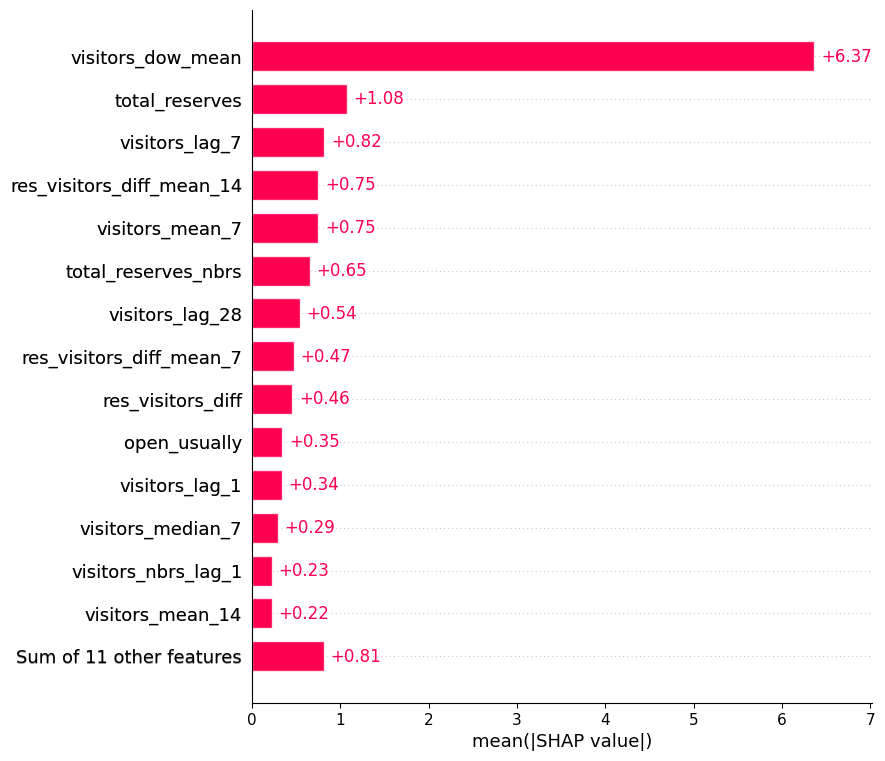

In [20]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

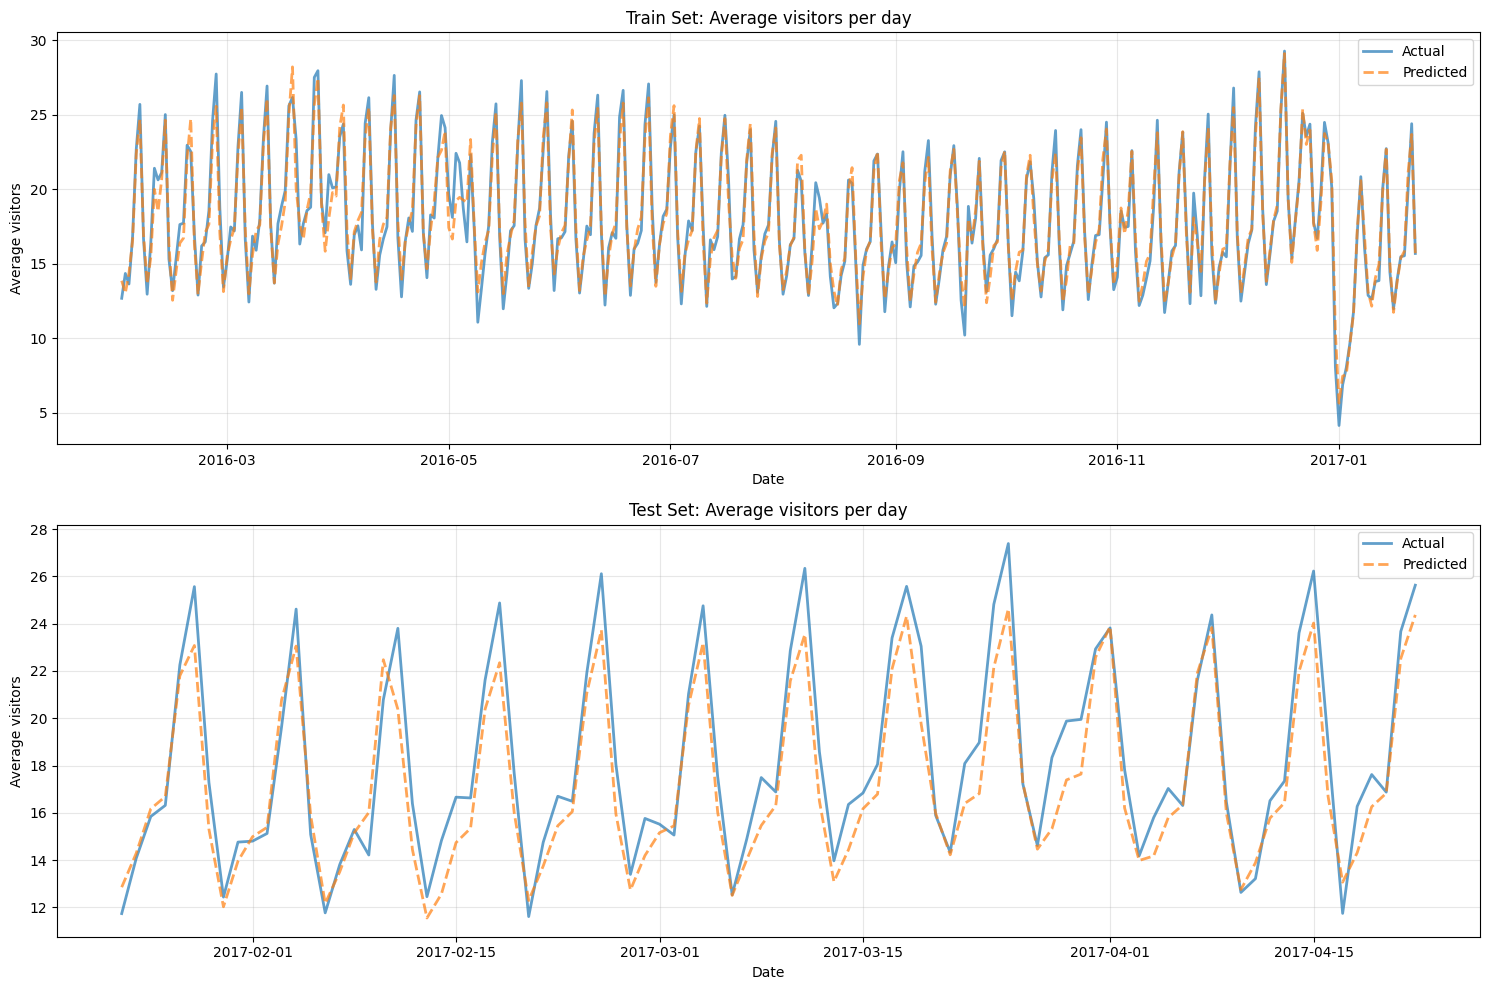

In [23]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [23]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [24]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 1.31304461  1.1811168  10.04338019  5.33133499 21.75563412 24.85782781
 25.67954531  1.48682049 37.12246924  1.93247327 21.10720743  5.10344458
 28.03437428 48.26996216 23.81974802  4.99195718 14.33729    11.0707185
 23.25010644 47.77680323  6.03344872 11.67942329 12.88923346 17.13872623
  1.59036821 27.50791187 12.35089451 16.04058614  1.48018851 13.8395254
 20.54343345  3.74829755 18.41957038  9.14497491  7.40098156  4.20312374
  2.73784468 32.7203786  22.38589239 12.41797366 34.40944879 37.73251925
  6.14724132  1.13370621 16.02187352 15.41268468  1.20470988 11.60703385
 29.77686864 25.53648226  1.17281163  2.30003527 20.93564576 11.17848439
  1.07051344  7.40564546  1.66556258 11.41821684 10.90836471 36.13726

In [25]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [22]:
joblib.dump(model, MODEL_PATH)

params_to_save = {
    "best_params": convert_to_serializable(grid_search.best_params_),
    "best_score": float(grid_search.best_score_),
    "std": float(grid_search.cv_results_["std_test_score"][best_idx]),
    "features": FEATURES_TO_KEEP
}

params_path = MODELS_DIR / "lightgbm_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)